# Artificial Neural Networks (ANN)

Neural networks are machine learning models that can be used to approximate any non-linear function. In this tutorial, we will first go through an example of how neural networks can be implemented in tensorflow (based on this [notebook](https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb) from Géron), and then look at an example of applying a neural network to a climate data set.

## Implementing MLP's with sci-kit learn

First, we will look at using `sci-kit learn` to implement a Multi-layer Perceptron (MLP) on the Iris data set.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

The Iris data set is a simple example data that includes values for 4 features:
~~~
-sepal length (cm)
-sepal width (cm)
-petal length (cm)
-petal width (cm)
~~~
for labeled data sets of 3 different iris types ['setosa', 'versicolor', 'virginica']. The problem is to classify each sample as belonging to one of these 3 iris types, based on the values of these 4 features.

In [2]:
iris = load_iris()

In [3]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    iris.data, iris.target, test_size=0.1, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42)

In the `sci-kit learn` implementation, we need to specify whether we are training an MLP for classification or regression. Here we use the `MLPClassifier` since we are interested in classifying each sample as belonging to one of the 3 iris types.

We can specify a number of hyper-parameters for the MLPClassifier:
- hidden_layer_sizes : the number of neurons in the ith hidden layer
- activation: the activation function to use. The default is relu
- max_iter : the maximum number of iterations
- etc.

In [4]:
mlp_clf = MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000,
                        random_state=42)

In [5]:
pipeline = make_pipeline(StandardScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_valid, y_valid)
accuracy

1.0

In [6]:
mlp_clf

,hidden_layer_sizes,[5]
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,10000
,shuffle,True
,random_state,42


## Implementing MLP's with Keras/Tensorflow
We would generally not use `sci-kit learn` to implement a neural network, because we don't have nearly as much flexibility to customize our deep learning models with this library as we do with libraries that are specifically developed for deep learning. Instead, we will use `Tensorflow` with its `Keras` backend as a deep learning library. 

To start, we will use a simple example of using the fashion MNIST data set (this is a simple example data set that includes examples of images of different items of clothing labeled by the type of clothing). We will just use this as an example for how one sets up and trains a machine learning model in `Tensorflow`


In [7]:
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

2025-07-29 03:42:18.168327: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-29 03:42:18.180084: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-29 03:42:18.194755: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-29 03:42:18.199540: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-29 03:42:18.210595: I tensorflow/core/platform/cpu_feature_guar

In [8]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

The training set contains 60,000 grayscale images, each 28x28 pixels.

In [9]:
X_train.shape

(55000, 28, 28)

Each pixel intensity is represented as a byte (0 to 255):

In [10]:
X_train.dtype

dtype('uint8')

Let's scale the pixel intensities down to the 0-1 range and convert them to floats, dividing by 255:

In [11]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

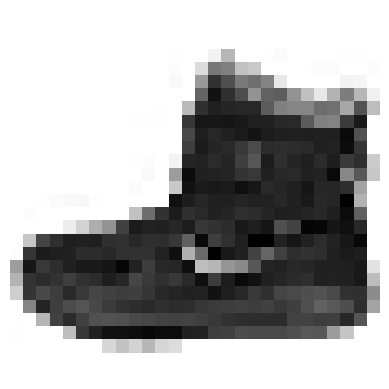

In [12]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDS, from 0 to 9:

In [13]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

The corresponding class names are 

In [14]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

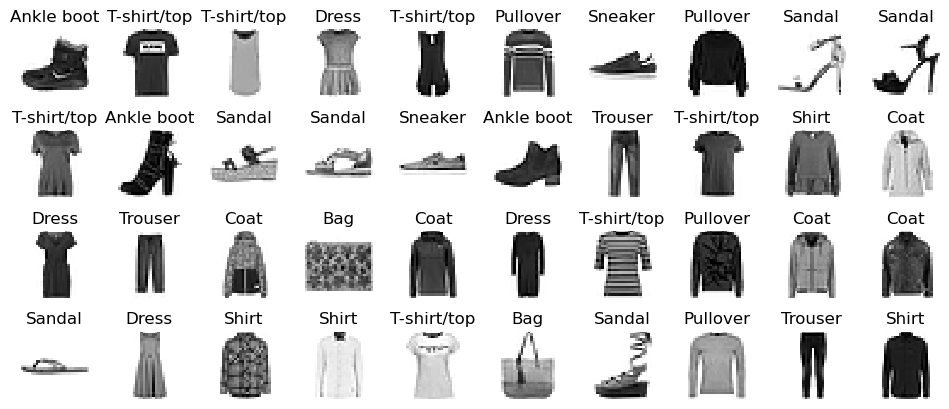

In [15]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

## Creating the model using the sequential API

In [16]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [17]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[28, 28]))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [18]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [21]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [22]:
model.get_layer('dense') is hidden1

True

In [23]:
weights, biases = hidden1.get_weights()
weights

array([[-0.02560823, -0.02634257,  0.07235377, ..., -0.04969896,
         0.03304707,  0.04589636],
       [ 0.06279328,  0.07435261,  0.00015049, ...,  0.00962216,
        -0.05195863,  0.06938753],
       [ 0.06117593,  0.06714574, -0.01730046, ..., -0.02778541,
         0.0411777 ,  0.05234522],
       ...,
       [ 0.00120796, -0.01475094, -0.04456412, ..., -0.04223892,
         0.05230567,  0.0318235 ],
       [ 0.00609792, -0.01868763, -0.04043633, ..., -0.00147494,
         0.04218294,  0.06880455],
       [-0.02529991,  0.0273062 ,  0.0497757 , ..., -0.00541577,
         0.03578426, -0.00982709]], dtype=float32)

In [24]:
weights.shape

(784, 300)

In [25]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [26]:
biases.shape

(300,)

## Compiling the model

In [27]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [28]:
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

## Training and evaluating the model

In [30]:
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.9984 - sparse_categorical_accuracy: 0.6858 - val_loss: 0.5039 - val_sparse_categorical_accuracy: 0.8272
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.5068 - sparse_categorical_accuracy: 0.8260 - val_loss: 0.4551 - val_sparse_categorical_accuracy: 0.8378
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.4541 - sparse_categorical_accuracy: 0.8431 - val_loss: 0.4344 - val_sparse_categorical_accuracy: 0.8444
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.4245 - sparse_categorical_accuracy: 0.8520 - val_loss: 0.4195 - val_sparse_categorical_accuracy: 0.8472
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.4029 - sparse_categorical_accuracy: 0.8581 - val_loss: 0.4090 - val_sparse_categorical_accuracy: 0.8500
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.3856 - sparse_categorical_accuracy: 0.8659 - val_loss: 0.3992 - val_sparse_categorical_accuracy:

In [31]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [32]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


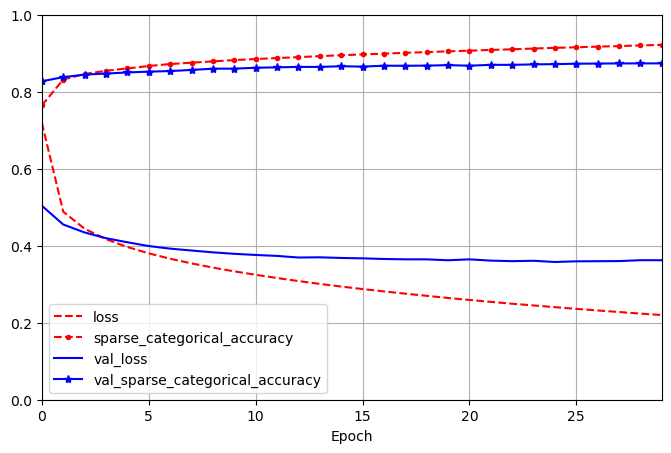

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code

plt.show()

In [35]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3832 - sparse_categorical_accuracy: 0.8699


[0.37980860471725464, 0.871399998664856]

## Using the model to make predictions

In [36]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.34, 0.  , 0.01, 0.  , 0.65],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [37]:
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1])

In [40]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [41]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

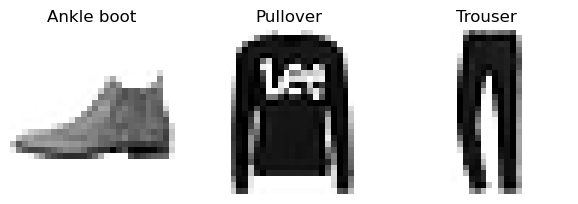

In [43]:
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

# Predicting global temperature from greenhouse gas concentrations

Here we will look at an example of using a neural network to predict the global temperature given the global atmospheric concentrations of CO2 and CH4. This is based on this [notebook](https://github.com/leap-stc/LEAP-bootcamps/blob/main/Codes/Day2/Neural_Network_example.ipynb) developed by Weiwei Zhan.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from glob import glob

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import *
from tensorflow.keras import Sequential

2025-07-29 04:36:44.267640: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-29 04:36:44.279508: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-29 04:36:44.294789: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-29 04:36:44.300062: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-29 04:36:44.311873: I tensorflow/core/platform/cpu_feature_guar

In [2]:
cwd = os.getcwd()
train_path = "gs://leap-persistent/jbusecke/data/climatebench/train_val/"
test_path = "gs://leap-persistent/jbusecke/data/climatebench/test/"

## Visualization of the ClimateBench Data 

ClimateBench is a spatial-temporal dataset that contains simulations generated by the NorESM2 climate model. It provides both historical simulations & future projections under different scenarios (e.g., ssp245).

Four future scenarios are plotted here: ssp126, ssp245, ssp370, ssp585. These scenarios make different assumptions about future anthropogenic emissions.

In [3]:
def open_dataset(file_path):
    """Flexible opener that can handle both local files (legacy) and cloud urls. IMPORTANT: For this to work the `file_path` must be provided without extension."""
    if 'gs://' in file_path:
        store = f"{file_path}.zarr"
        ds = xr.open_dataset(store, engine='zarr')
    else:
        ds = xr.open_dataset(f"{file_path}.nc")
        # add information to sort and label etc
        ds.attrs['file_name']
    return ds

In [4]:
scenarios = ['historical','ssp126','ssp370','ssp585']
inputs = [os.path.join(train_path , f"inputs_{scenario}") for scenario in scenarios]
inputs.append(os.path.join(test_path, "inputs_ssp245"))
inputs.sort(key=lambda x:x.split('_')[-1])

outputs = [os.path.join(train_path , f"outputs_{scenario}") for scenario in scenarios]
outputs.append(os.path.join(test_path, "outputs_ssp245"))
outputs.sort(key=lambda x:x.split('_')[-1])

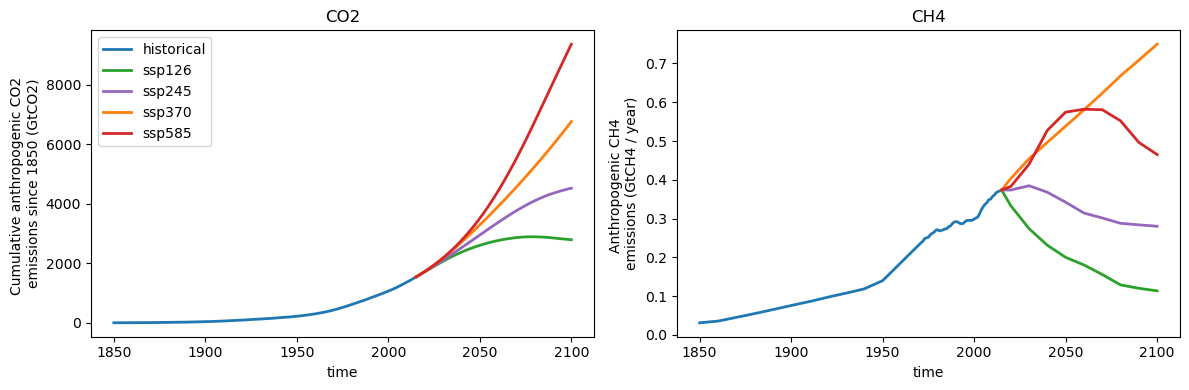

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
colors  = ['tab:blue','tab:green','tab:purple','tab:orange','tab:red']


for i,input in enumerate(inputs):

    label=input.split('_')[-1]#[:-3]
    X = open_dataset(input)
    x = X.time.data
    
    X['CO2'].plot(label=label,color=colors[i],linewidth=2,ax=axes[0])

    axes[0].set_ylabel("Cumulative anthropogenic CO2 \nemissions since 1850 (GtCO2)")
    
    X['CH4'].plot(label=label,color=colors[i],linewidth=2,ax=axes[1])

    axes[1].set_ylabel("Anthropogenic CH4 \nemissions (GtCH4 / year)")
    
axes[0].set_title('CO2')
axes[1].set_title('CH4')
axes[0].legend()
plt.tight_layout()

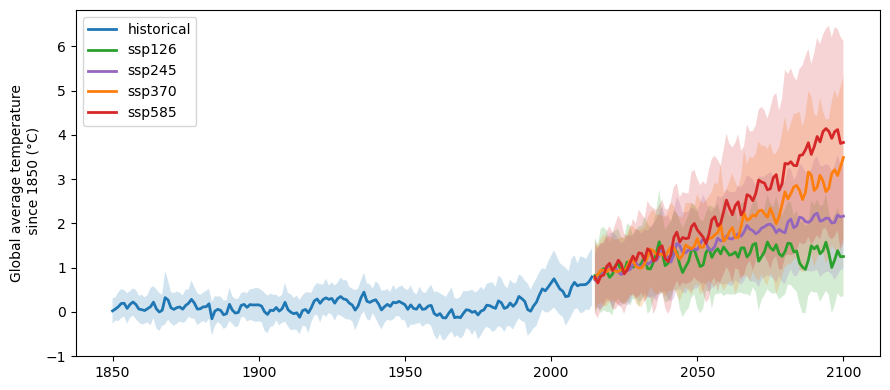

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(9,4))

for i,output in enumerate(outputs):

    label=output.split('_')[-1]#[:-3]
    X = open_dataset(output).mean(dim="member")[['tas']].drop_vars(['quantile'])
    x = X.time.data
    
    weights  = np.cos(np.deg2rad(X.lat))
    tas_mean = X['tas'].weighted(weights).mean(['lat', 'lon']).data
    tas_std  = X['tas'].weighted(weights).std(['lat', 'lon']).data
    
    ax.plot(x, tas_mean, label=label,color=colors[i],linewidth=2)
    ax.fill_between(x,tas_mean+tas_std,tas_mean-tas_std,facecolor=colors[i],alpha=0.2)
    
ax.set_ylabel("Global average temperature\n since 1850 (°C)")
ax.legend()
plt.tight_layout()

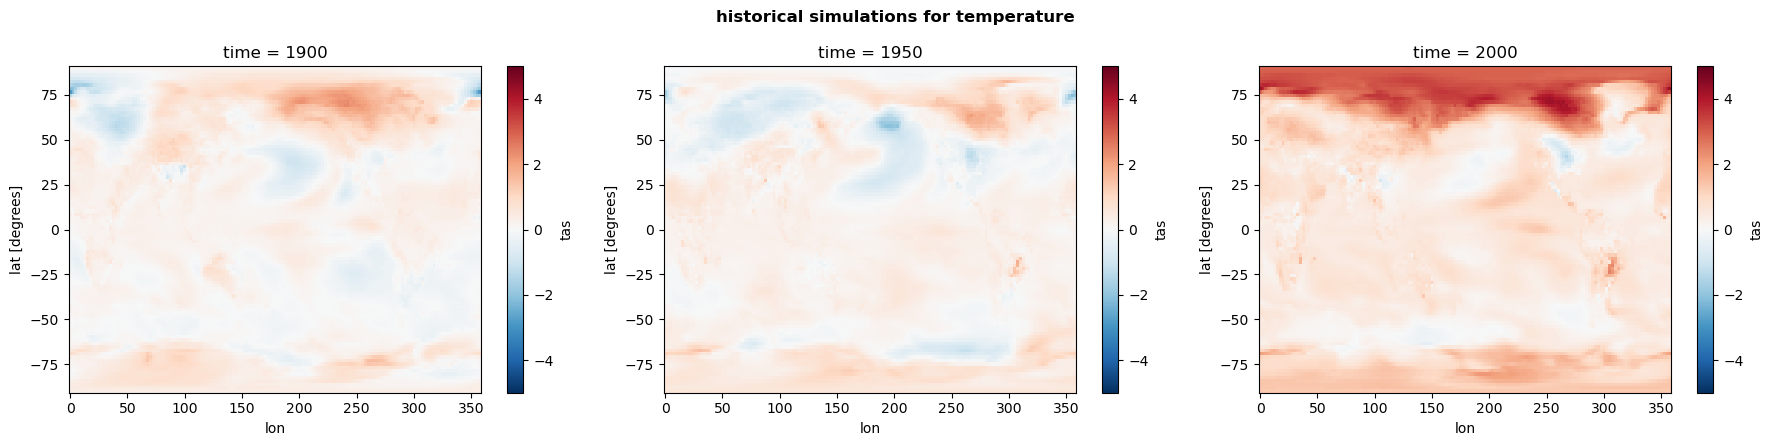

In [7]:
y_his    = open_dataset(os.path.join(train_path , "outputs_historical")).mean(dim="member")[['tas']].drop_vars(['quantile'])
y_ssp370 = open_dataset(os.path.join(train_path,'outputs_ssp370')).mean(dim="member")[['tas']].drop_vars(['quantile'])

fig,axes = plt.subplots(figsize=(18,4.5),ncols=3)
yr0, yr1, yr2 = 1900, 1950, 2000
vmin, vmax = -5, 5

y_his.sel(time=yr0).tas.plot(ax=axes.flat[0],vmin=vmin,vmax=vmax,cmap='RdBu_r')
y_his.sel(time=yr1).tas.plot(ax=axes.flat[1],vmin=vmin,vmax=vmax,cmap='RdBu_r')
y_his.sel(time=yr2).tas.plot(ax=axes.flat[2],vmin=vmin,vmax=vmax,cmap='RdBu_r')

fig.suptitle('historical simulations for temperature',fontweight='bold')
plt.tight_layout()

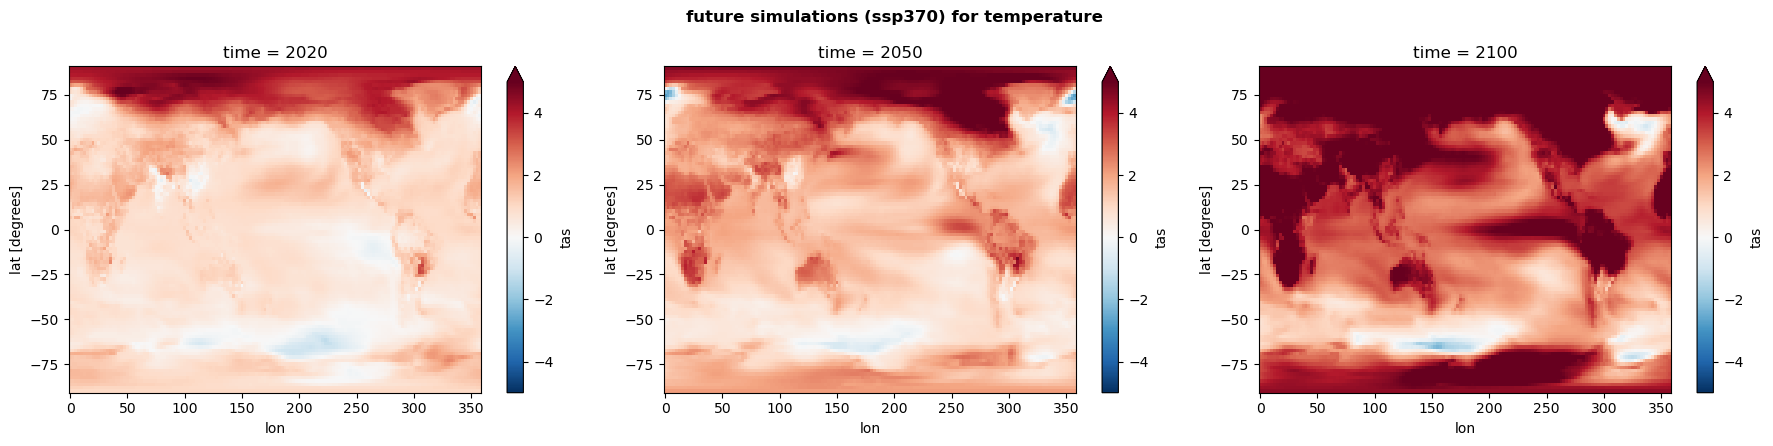

In [8]:
y_ssp370 = open_dataset(os.path.join(train_path,'outputs_ssp370')).mean(dim="member")[['tas']].drop_vars(['quantile'])


fig,axes = plt.subplots(figsize=(18,4.5),ncols=3)
yr0, yr1, yr2 = 2020, 2050, 2100
vmin, vmax = -5, 5

y_ssp370.sel(time=yr0).tas.plot(ax=axes.flat[0],vmin=vmin,vmax=vmax,cmap='RdBu_r')
y_ssp370.sel(time=yr1).tas.plot(ax=axes.flat[1],vmin=vmin,vmax=vmax,cmap='RdBu_r')
y_ssp370.sel(time=yr2).tas.plot(ax=axes.flat[2],vmin=vmin,vmax=vmax,cmap='RdBu_r')

fig.suptitle('future simulations (ssp370) for temperature',fontweight='bold')
plt.tight_layout()

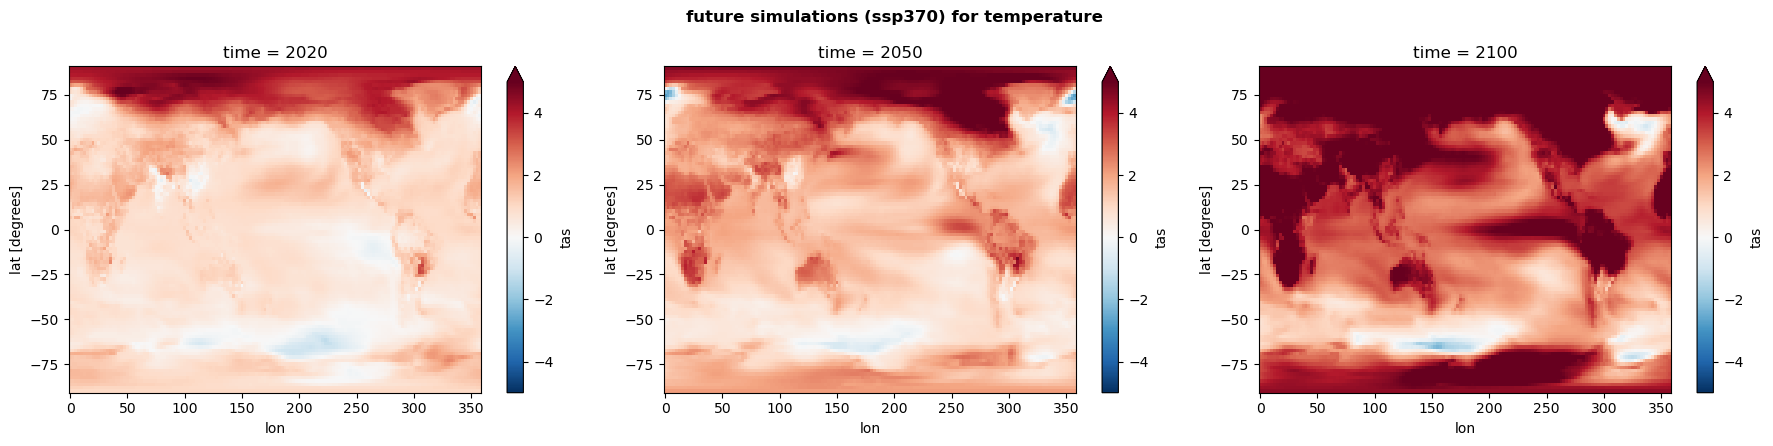

In [9]:
y_ssp370 = open_dataset(os.path.join(train_path,'outputs_ssp370')).mean(dim="member")[['tas']].drop_vars(['quantile'])


fig,axes = plt.subplots(figsize=(18,4.5),ncols=3)
yr0, yr1, yr2 = 2020, 2050, 2100
vmin, vmax = -5, 5

y_ssp370.sel(time=yr0).tas.plot(ax=axes.flat[0],vmin=vmin,vmax=vmax,cmap='RdBu_r')
y_ssp370.sel(time=yr1).tas.plot(ax=axes.flat[1],vmin=vmin,vmax=vmax,cmap='RdBu_r')
y_ssp370.sel(time=yr2).tas.plot(ax=axes.flat[2],vmin=vmin,vmax=vmax,cmap='RdBu_r')

fig.suptitle('future simulations (ssp370) for temperature',fontweight='bold')
plt.tight_layout()

## Data preprocessing
We will train the NN using simulations from 3 historical and 3 future scenarios. We will then test the trained NN on the ssp245 scenario. 

In [10]:
def prepare_predictor(data_sets, data_path,time_reindex=True):
    """
    Args:
        data_sets list(str): names of datasets
    """
        
    # Create training and testing arrays
    if isinstance(data_sets, str):
        data_sets = [data_sets]
        
    X_all      = []
    length_all = []
    
    for file in data_sets:
        data = open_dataset(f"{data_path}inputs_{file}")
        X_all.append(data)
        length_all.append(len(data.time))
    
    X = xr.concat(X_all,dim='time')
    length_all = np.array(length_all)

    if time_reindex:
        X = X.assign_coords(time=np.arange(len(X.time)))

    return X, length_all
def prepare_predictand(data_sets,data_path,time_reindex=True):
    if isinstance(data_sets, str):
        data_sets = [data_sets]
        
    Y_all = []
    length_all = []
    
    for file in data_sets:
        data = open_dataset(f"{data_path}outputs_{file}")
        Y_all.append(data)
        length_all.append(len(data.time))
    
    length_all = np.array(length_all)
    Y = xr.concat(Y_all,dim='time').mean('member')
    Y = Y.rename({'lon':'longitude','lat': 'latitude'}).transpose('time','latitude', 'longitude').drop_vars(['quantile'])
    if time_reindex:
        Y = Y.assign_coords(time=np.arange(len(Y.time)))
    
    return Y, length_all

In [11]:
# Training set
train_files    = ["historical", "ssp585", "ssp126", "ssp370","hist-aer","hist-GHG"]
X_train_xr, _  = prepare_predictor(train_files,train_path)
y_train_xr, _  = prepare_predictand(train_files,train_path)

# Test set
X_test_xr, _ = prepare_predictor('ssp245', data_path=test_path,time_reindex=False)
y_test_xr, _ = prepare_predictand('ssp245',data_path=test_path,time_reindex=False)

In [12]:
X_train_df = pd.DataFrame({"CO2": X_train_xr["CO2"].data,
                           "CH4": X_train_xr["CH4"].data
                          }, index=X_train_xr["CO2"].coords['time'].data)

X_test_df  = pd.DataFrame({"CO2": X_test_xr["CO2"].data,
                           "CH4": X_test_xr["CH4"].data
                          }, index=X_test_xr["CO2"].coords['time'].data)

In [13]:
y_train_df = y_train_xr["tas"].stack(z=("latitude", "longitude"))
y_train_df = pd.DataFrame(y_train_df.to_pandas())

In [14]:
X_train_df.head()

,CO2,CH4
0,0.188297,0.031306
1,0.377244,0.031742
2,0.573814,0.032178
3,0.778848,0.032614
4,1.020320,0.033049


In [17]:
print(len(y_train_df))
y_train_df.head()

753


latitude      -90.0                                                    \
longitude     0.0       2.5       5.0       7.5       10.0      12.5    
time                                                                    
0          0.320023  0.319946  0.319865  0.319885  0.319860  0.319865   
1         -0.667297 -0.667023 -0.667114 -0.667109 -0.667109 -0.667135   
2         -0.058345 -0.058167 -0.058248 -0.058243 -0.058248 -0.058248   
3          0.125870  0.125941  0.125946  0.125941  0.125946  0.125890   
4          0.418304  0.418533  0.418503  0.418523  0.418477  0.418513   

latitude                                           ...      90.0            \
longitude     15.0      17.5      20.0      22.5   ...     335.0     337.5   
time                                               ...                       
0          0.319870  0.319911  0.319763  0.319707  ...  0.913116  0.913289   
1         -0.667114 -0.667104 -0.667104 -0.666992  ...  0.042501  0.042679   
2         -0.058233 -0.058207 -0.058345 -0.058177  ...  1.167440  1.167389   
3          0.125951  0.125941  0.125895  0.125982  ... -0.339457 -0.339589   
4          0.418503  0.418549  0.418482  0.418564  ...  0.577006  0.576996   

latitude                                                               \
longitude     340.0     342.5     345.0     347.5     350.0     352.5   
time                                                                    
0          0.913116  0.912933  0.912893  0.912659  0.912384  0.912181   
1          0.049225  0.055695  0.055506  0.055227  0.054789  0.054230   
2          1.169657  1.172119  1.172201  1.172190  1.172292  1.172424   
3         -0.332387 -0.324961 -0.324956 -0.325038 -0.325063 -0.325033   
4          0.585297  0.593811  0.593740  0.593719  0.593648  0.593801   

latitude                       
longitude     355.0     357.5  
time                           
0          0.911825  0.911611  
1          0.053604  0.052897  
2          1.172709  1.173228  
3         -0.325022 -0.324880  
4          0.593760  0.593943  

[5 rows x 13824 columns]

## Data normalization

In [18]:
# Standardization
mean, std = X_train_df.mean(), X_train_df.std()

X_train_df   = (X_train_df - mean)/std
X_test_df    = (X_test_df - mean)/std

X_train = X_train_df.to_numpy()
y_train = y_train_df.to_numpy()
X_test = X_test_df.to_numpy()

print(X_train.shape,y_train.shape)

(753, 2) (753, 13824)


## Define the neural network structure

Here we will use a neural network that has 3 hidden layers, and each hidden layer has 64 neurons. The input to the neural network will be the CO2 and CH4 concentrations at each time step. 

The neural network outputs are the global surface temperatures (tas), with each neuron of the output layer corresponding to each pixel. There are 13824 pixels in total (96 latitude and 144 longitude).

In [19]:
# set hyperparameters
n_neuron       = 64
activation     = 'relu'
num_epochs     = 50
learning_rate  = 0.001
minibatch_size = 64
model_num      = 1
N_layers       = 3 # number of hidden layers

In [20]:
tf.keras.backend.clear_session()
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu",name="hidden_layer_1"),
    tf.keras.layers.Dense(64, activation="relu",name="hidden_layer_2"),
    tf.keras.layers.Dense(64, activation="relu",name="hidden_layer_3"),
    tf.keras.layers.Dense(y_train.shape[1],activation='linear',name="output_layer")
])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 13824)          │       898,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 907,072 (3.46 MB)

 Trainable params: 907,072 (3.46 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(loss='mse',optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))

In [23]:
model.compile(loss='mse',optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))

## Train the Neural Network and Save its weights

In [24]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20)


history = model.fit(X_train, y_train, 
                    batch_size      = minibatch_size,
                    epochs          = num_epochs,
                    validation_split= 0.2, 
                    verbose         = 1,
                    callbacks       = [early_stop])

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 3.6055 - val_loss: 0.5553
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 3.6088 - val_loss: 0.5001
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.3417 - val_loss: 0.3936
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.3798 - val_loss: 0.2823
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.7631 - val_loss: 0.2809
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4696 - val_loss: 0.2937
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4290 - val_loss: 0.2846
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.4147 - val_loss: 0.2902
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4079 - val_loss: 0.2804
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.3832 - val_loss: 0.2745
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.3950 - val_loss: 0.2655
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.3

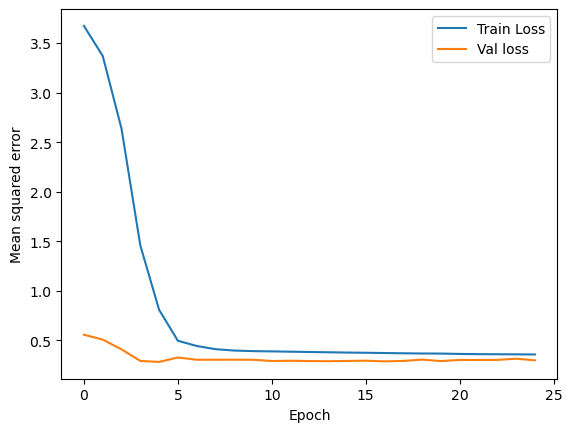

In [25]:
plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean squared error')
plt.plot(history.epoch, np.array(history.history['loss']),label='Train Loss')
plt.plot(history.epoch, np.array(history.history['val_loss']),label = 'Val loss')
plt.legend()

In [28]:
model_path = os.path.join(cwd,'saved_model')
if os.path.exists(model_path) is False:
    os.makedirs(model_path)

In [29]:
# Save the entire model to a HDF5 file.
# The '.h5' extension indicates that the model should be saved to HDF5.
model.save(os.path.join(model_path,'NN_model.keras'))

## Evaluate the trained model

We will evaluate the trained neural network on the test data set by comparing the neural network predictions against the original surface temperatures simulated under the ssp245 scenario.

In [30]:
# reload the saved model
model = load_model(os.path.join(model_path,'NN_model.keras'))

In [31]:
y_test_pre = model.predict(X_test)
y_test_pre = y_test_pre.reshape(y_test_pre.shape[0], 96, 144)

y_test_pre = xr.Dataset(coords={'time': X_test_xr.time.values, 
                               'latitude': X_test_xr.latitude.values, 
                               'longitude': X_test_xr.longitude.values},
                       data_vars=dict(tas=(['time', 'latitude', 'longitude'], y_test_pre)))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


First we check whether the ML model can capture the spatial distribution of global temperatures.

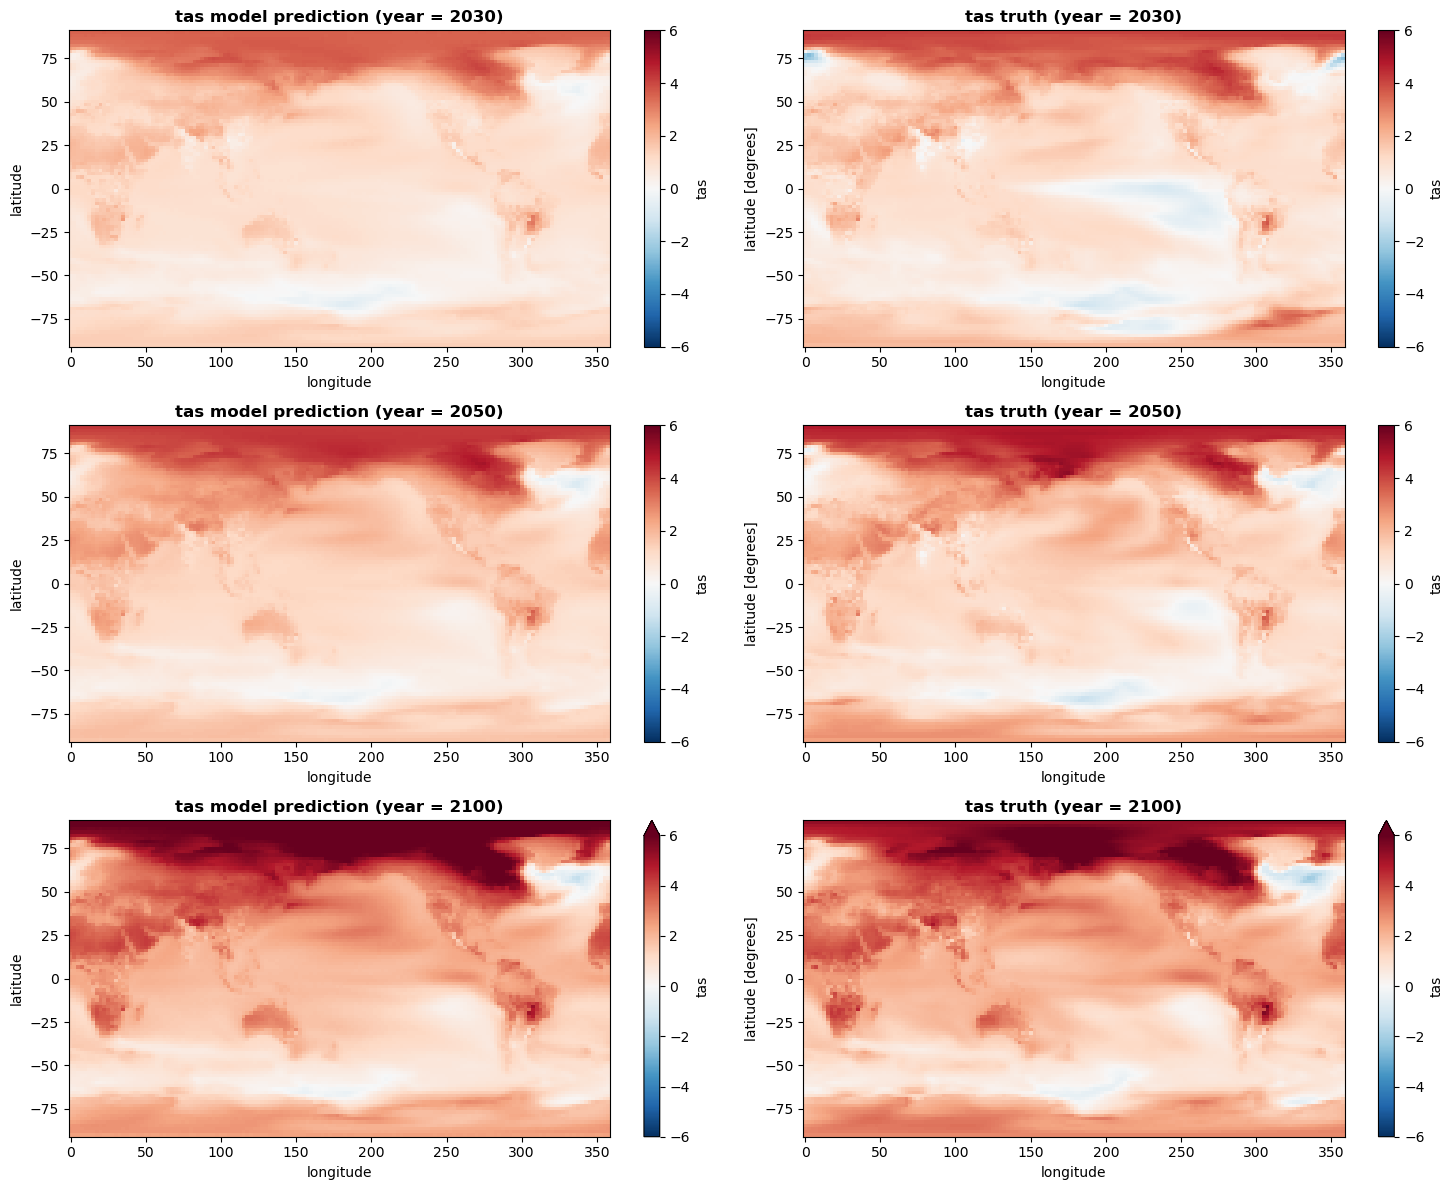

In [32]:
fig, axes = plt.subplots(figsize=(15,12),ncols=2,nrows=3)

yrs = [2030, 2050, 2100]
vmin, vmax    = -6, 6
cmap = 'RdBu_r'
y_test_pre.tas.sel(time=yrs[0]).plot(ax=axes[0,0], vmin=vmin, vmax=vmax,cmap=cmap)
y_test_xr.tas.sel(time=yrs[0]).plot(ax=axes[0,1], vmin=vmin, vmax=vmax,cmap=cmap)

y_test_pre.tas.sel(time=yrs[1]).plot(ax=axes[1,0], vmin=vmin, vmax=vmax,cmap=cmap)
y_test_xr.tas.sel(time=yrs[1]).plot(ax=axes[1,1], vmin=vmin, vmax=vmax,cmap=cmap)

y_test_pre.tas.sel(time=yrs[2]).plot(ax=axes[2,0], vmin=vmin, vmax=vmax,cmap=cmap)
y_test_xr.tas.sel(time=yrs[2]).plot(ax=axes[2,1], vmin=vmin, vmax=vmax,cmap=cmap)


for i, ax in enumerate(axes.flat):
    # left column: model prediction
    if i % 2 == 0:
        ax.set_title(f'tas model prediction (year = {yrs[i//2]})',fontweight='bold')
    # right column: truth tas from ssp245 simulations
    else:
        ax.set_title(f'tas truth (year = {yrs[i//2]})',fontweight='bold')
plt.tight_layout()

Then we will also check how well the ML model can reproduce the time series of a given location. Here we will take NYC as an example (40.7128° N, 74.0060° W)

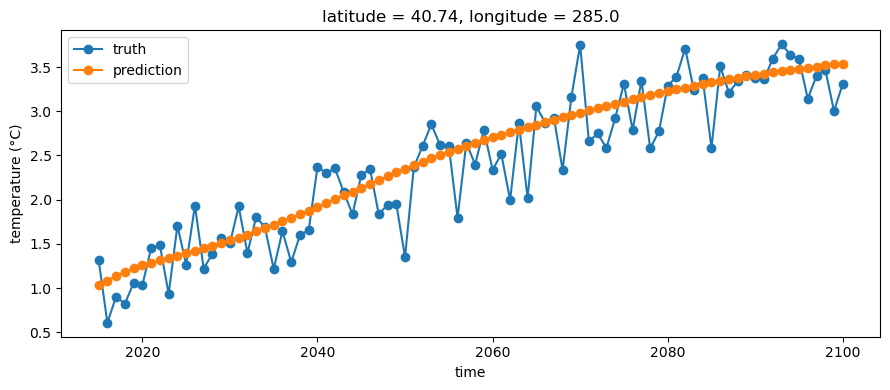

In [33]:
	
lat = 40.7128
lon = -74.0060%360

fig,ax = plt.subplots(figsize=(9,4))
y_test_xr.sel(latitude=lat,longitude=lon,method='nearest').tas.plot(marker='o',ax=ax,label='truth')
y_test_pre.sel(latitude=lat,longitude=lon,method='nearest').tas.plot(marker='o',ax=ax,label='prediction')

ax.legend()
ax.set_ylabel('temperature (°C)')

plt.tight_layout()

Finally, we will check whether the ML model can capture the time series of global average temperature

In [34]:
def global_mean_std_plot(X,label,color,ax,var='tas'):
    weights  = np.cos(np.deg2rad(X.latitude))
    tas_mean = X[var].weighted(weights).mean(['latitude', 'longitude']).data
    tas_std  = X[var].weighted(weights).std(['latitude', 'longitude']).data
    
    x = X.time.data

    ax.plot(x, tas_mean, label=label,color=color,linewidth=2)
    ax.fill_between(x,tas_mean+tas_std,tas_mean-tas_std,facecolor=color,alpha=0.2)

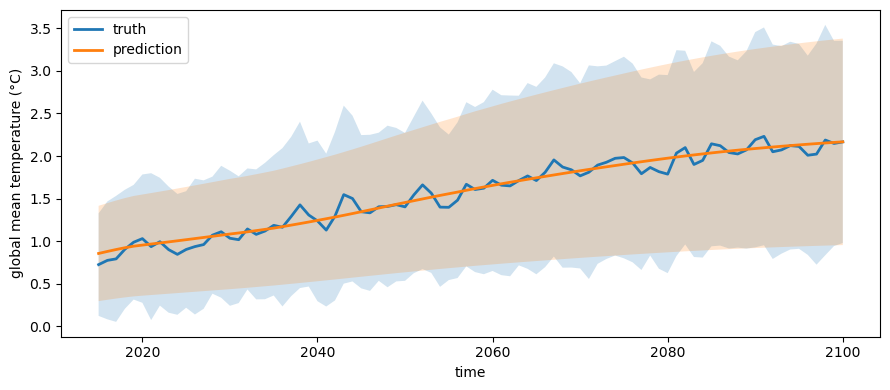

In [35]:
fig,ax = plt.subplots(figsize=(9,4))

global_mean_std_plot(y_test_xr,label='truth',ax=ax,color='tab:blue')
global_mean_std_plot(y_test_pre,label='prediction',ax=ax,color='tab:orange')

ax.set_xlabel('time')
ax.set_ylabel('global mean temperature (°C)')
ax.legend()
plt.tight_layout()